<a href="https://colab.research.google.com/github/barrynauta/portefee/blob/main/portefee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧚 Portefee — Portfolio Visualization

Visualizes your stock & ETF portfolio with:
- **Per-stock/ETF charts** — market price evolution with buy-point annotations
- **Combined portfolio chart** — total market value vs. cost basis over time

Data sourced from your Notion "Stocks and ETFs" database.  
Market prices pulled from Yahoo Finance.

## 1. Setup & Install

In [21]:
!pip install -q yfinance matplotlib pandas python-dateutil scipy

In [22]:
import os
import warnings
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")

# Output directory (in Google Drive if mounted, otherwise local)
USE_DRIVE = False  # @param {type:"boolean"}

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/portefee/charts'
else:
    OUT_DIR = '/content/portefee_charts'

os.makedirs(OUT_DIR, exist_ok=True)
print(f"Charts will be saved to: {OUT_DIR}")

Charts will be saved to: /content/portefee_charts


## 2. Portfolio Data

Ticker mapping and buy history from Notion.  
Update this section when you make new purchases.

In [23]:
# ─── Yahoo Finance ticker mapping ───────────────────────────
TICKER_MAP = {
    "MSFT":   "MSFT",
    "GOOGL":  "GOOGL",
    "NVDA":   "NVDA",
    "AMZN":   "AMZN",
    "BEL20":  "BEL.BR",
}

# ─── Currency per position ──────────────────────────────────
TICKER_CURRENCY = {
    "MSFT": "USD", "GOOGL": "USD", "NVDA": "USD", "AMZN": "USD",
    "BEL20": "EUR",
}

In [24]:
# ─── Buy history ───────────────────────────────────────────
# Format: (date, num_shares, price_per_share, total_costs)
# Fictive list, provide your own
# Prices in native currency of the instrument

BUYS = {
    "MSFT": [
        ("2022-07-27", 5,  264.29, 22.04),
        ("2025-10-29", 15, 542.00, 0.00),
        ("2026-02-23", 4,  395.00, 5.55),
    ],
    "GOOGL": [
        ("2022-08-16", 15, 122.00, 25.95),
        ("2024-10-02", 16, 167.78, 16.55),
        ("2025-10-24", 12, 260.79, 18.33),
    ],
    "NVDA": [
        ("2024-12-27", 145, 138.51, 131.11),
        ("2025-08-28", 60,  180.93, 63.38),
        ("2025-09-29", 50,  181.62, 52.72),
    ],
    "AMZN": [
        ("2022-08-22", 15, 135.00, 28.02),
        ("2024-12-17", 13, 232.40, 19.59),
    ],
    "BEL20": [
        ("2025-12-05", 1, 76.16, 0.09),
        ("2026-01-05", 1, 75.95, 0.09),
        ("2026-02-05", 1, 81.87, 0.10),
    ],
}

## 3. Helper Functions

In [25]:
def get_earliest_buy(buys_dict: dict) -> str:
    """Return the earliest buy date across all positions."""
    all_dates = [d for positions in buys_dict.values() for d, *_ in positions]
    return min(all_dates)


def download_price_history(yf_ticker: str, start: str) -> pd.DataFrame:
    """Download daily close prices from Yahoo Finance."""
    try:
        df = yf.download(yf_ticker, start=start, progress=False)
        if df.empty:
            return pd.DataFrame()
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        return df[["Close"]].rename(columns={"Close": "price"})
    except Exception as e:
        print(f"  ⚠️  Failed to download {yf_ticker}: {e}")
        return pd.DataFrame()


def compute_cumulative_shares(buy_list: list, date_index: pd.DatetimeIndex) -> pd.Series:
    """Given a list of buys, return cumulative shares held over time."""
    shares = pd.Series(0.0, index=date_index)
    for date_str, num, *_ in buy_list:
        dt = pd.Timestamp(date_str)
        shares[shares.index >= dt] += num
    return shares

## 4. Download Market Data

In [26]:
earliest = get_earliest_buy(BUYS)
start_date = (pd.Timestamp(earliest) - timedelta(days=30)).strftime("%Y-%m-%d")

print(f"📅 Downloading price data from {start_date} …\n")

prices = {}
failed = []

for name, yf_ticker in TICKER_MAP.items():
    if name not in BUYS:
        continue
    print(f"  📈 {name} ({yf_ticker}) …", end=" ")
    df = download_price_history(yf_ticker, start_date)
    if not df.empty:
        prices[name] = df
        print(f"✅ {len(df)} days")
    else:
        failed.append(name)
        print("❌ FAILED")

print(f"\n✅ Downloaded {len(prices)}/{len(BUYS)} tickers")
if failed:
    print(f"❌ Failed: {', '.join(failed)} — check Yahoo Finance ticker symbols")

📅 Downloading price data from 2022-06-27 …

  📈 MSFT (MSFT) … ✅ 927 days
  📈 GOOGL (GOOGL) … ✅ 927 days
  📈 NVDA (NVDA) … ✅ 927 days
  📈 AMZN (AMZN) … ✅ 927 days
  📈 BEL20 (BEL.BR) … ✅ 946 days

✅ Downloaded 5/5 tickers


## 5. Chart Style Configuration

In [27]:
# Dark theme for all charts
plt.rcParams.update({
    "figure.facecolor": "#1a1a2e",
    "axes.facecolor":   "#16213e",
    "axes.edgecolor":   "#e0e0e0",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#e0e0e0",
    "ytick.color":      "#e0e0e0",
    "text.color":       "#e0e0e0",
    "grid.color":       "#2a2a4a",
    "grid.alpha":       0.5,
    "font.size":        10,
})

print("🎨 Chart style configured")

🎨 Chart style configured


## 6. Per-Stock / ETF Charts

Each chart shows market price evolution with red triangle markers at buy points, annotated with shares × price.

Generating per-stock charts …

  ✅ MSFT


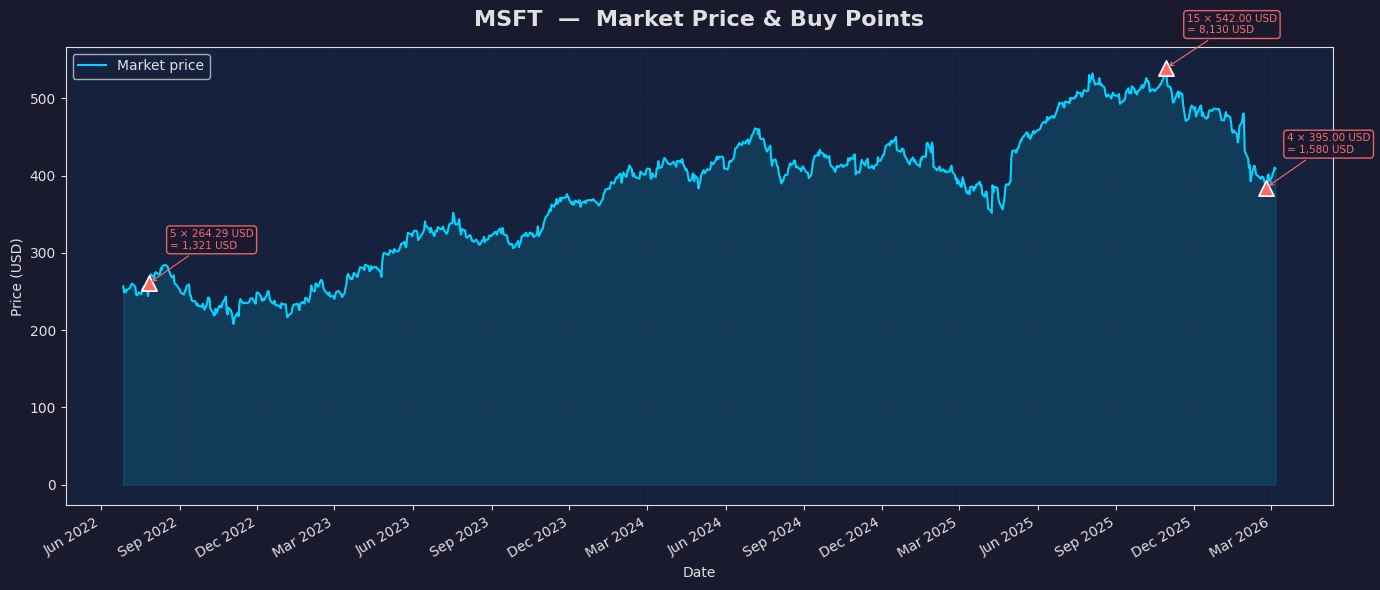

  ✅ GOOGL


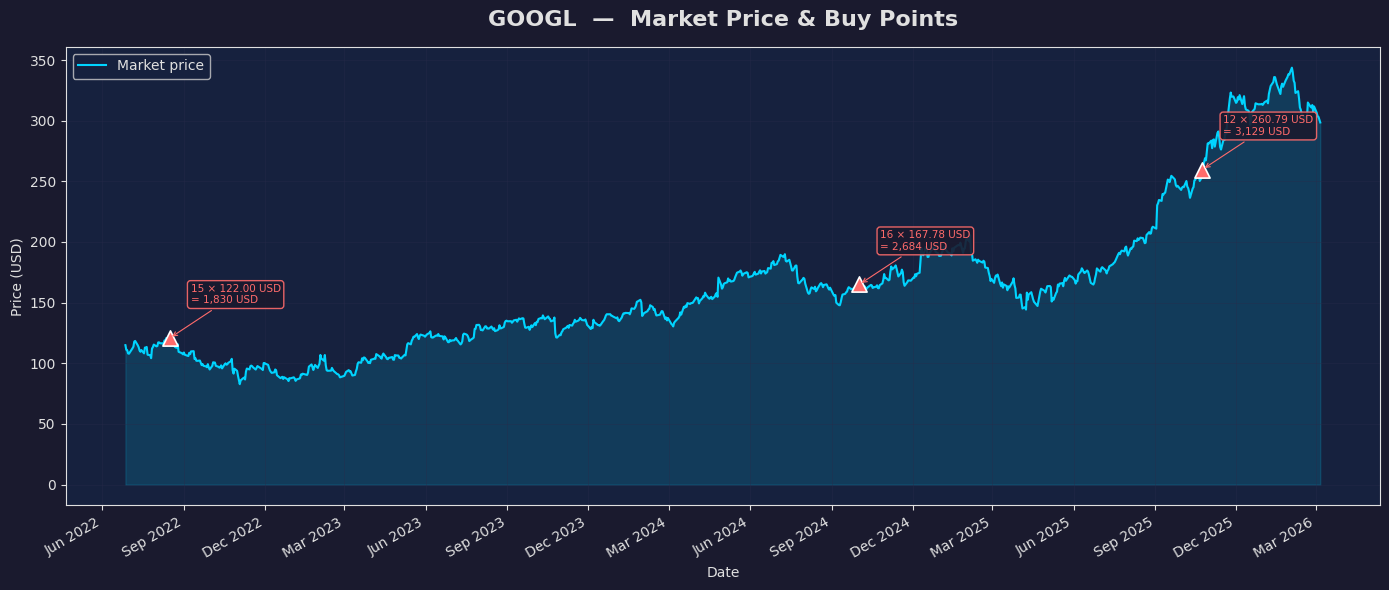

  ✅ NVDA


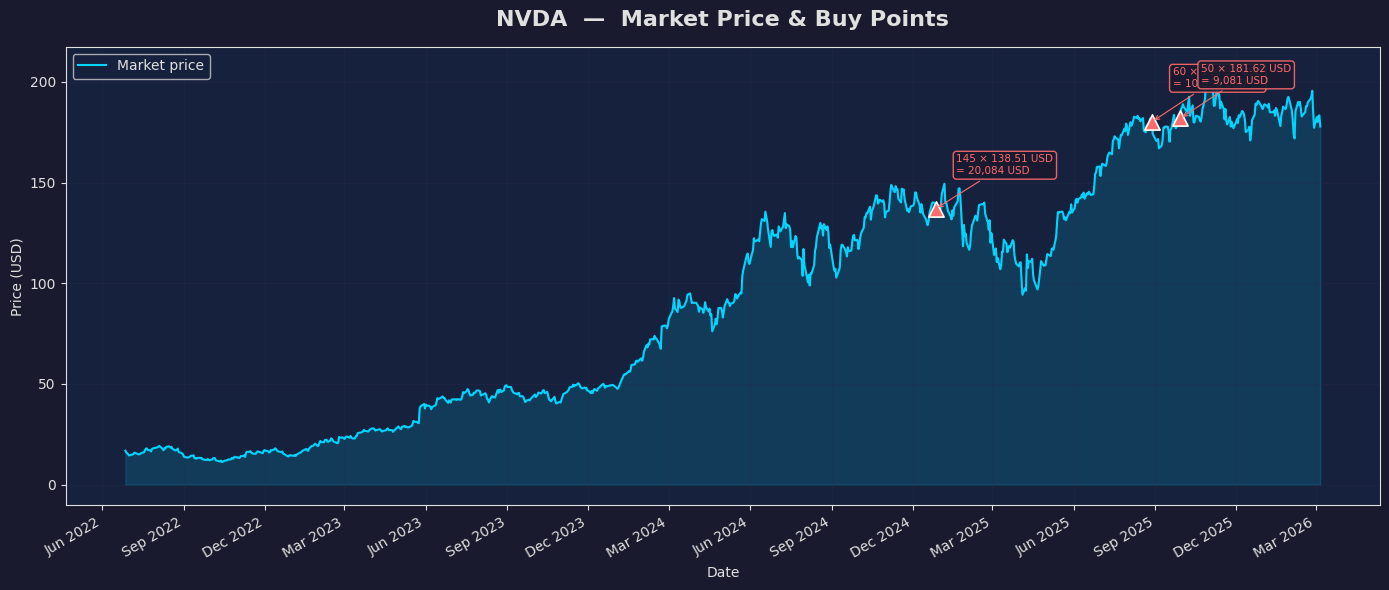

  ✅ AMZN


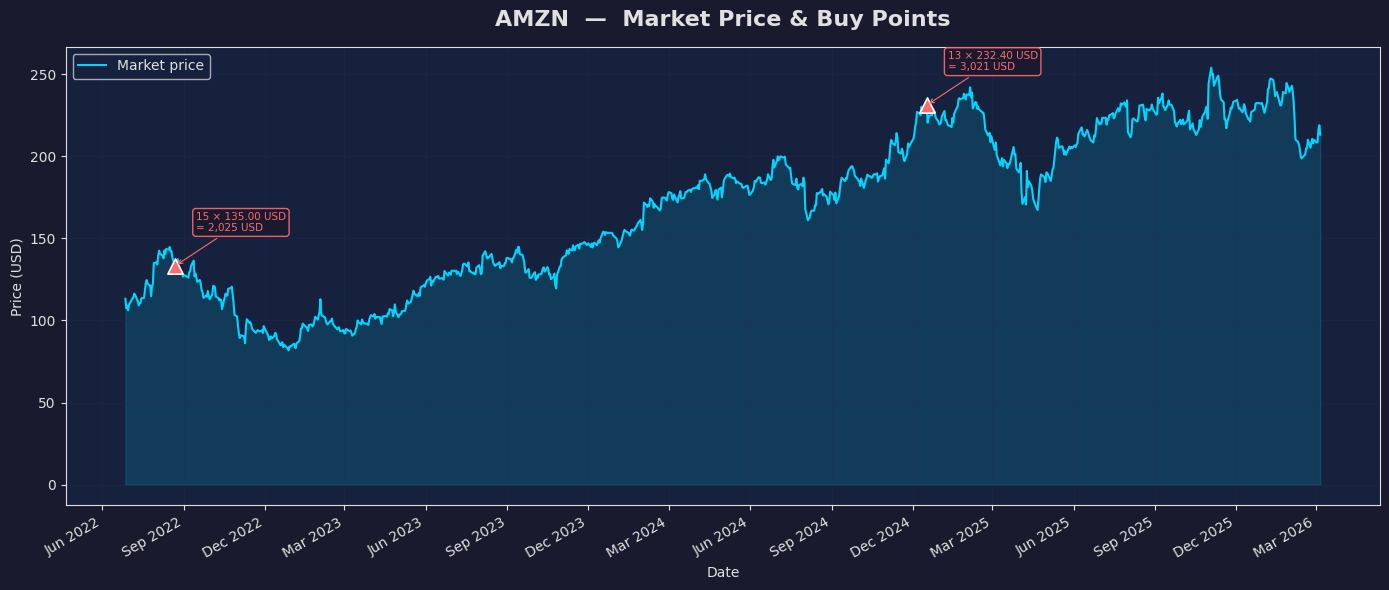

  ✅ BEL20


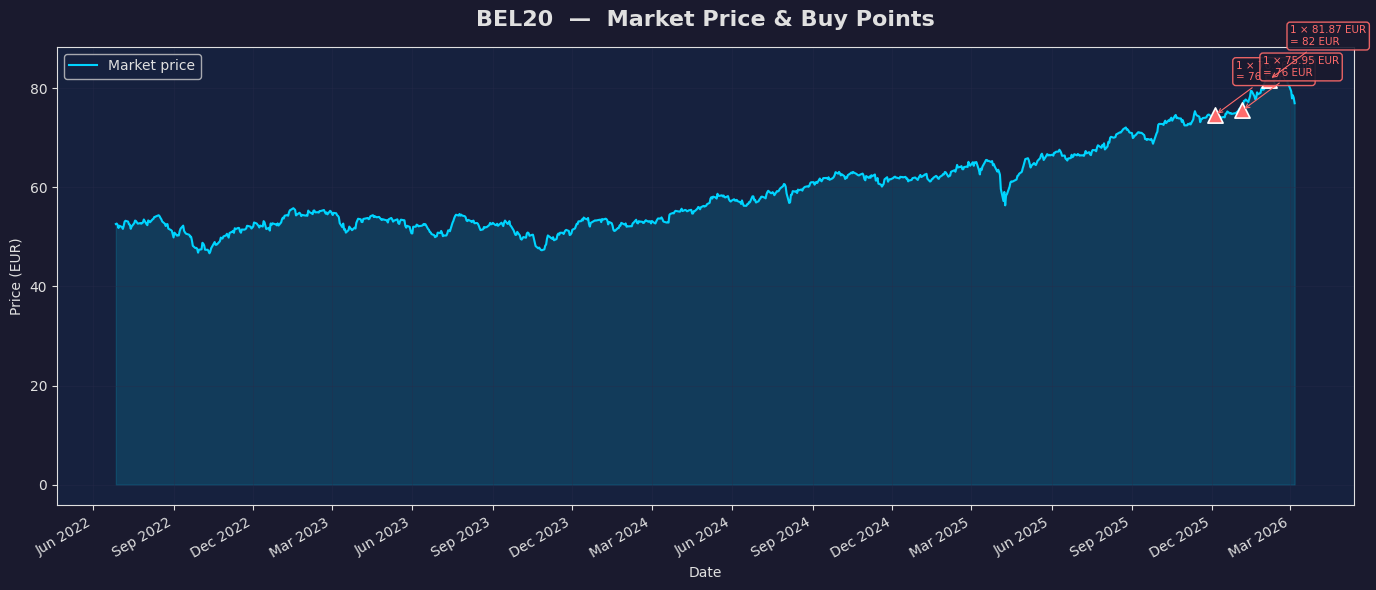


🎉 All per-stock charts saved to /content/portefee_charts


In [28]:
print("Generating per-stock charts …\n")

for name, df in prices.items():
    fig, ax = plt.subplots(figsize=(14, 6))

    # Price line
    ax.plot(df.index, df["price"], color="#00d4ff", linewidth=1.5,
            label="Market price", zorder=2)
    ax.fill_between(df.index, df["price"], alpha=0.15, color="#00d4ff")

    # Buy markers
    ccy = TICKER_CURRENCY.get(name, "")
    for date_str, num, price, costs in BUYS[name]:
        dt = pd.Timestamp(date_str)
        idx = df.index.get_indexer([dt], method="nearest")[0]
        if 0 <= idx < len(df):
            market_price = df["price"].iloc[idx]
            ax.scatter(df.index[idx], market_price,
                       color="#ff6b6b", s=120, zorder=5,
                       edgecolors="white", linewidths=1.2, marker="^")
            total = num * price
            ax.annotate(
                f"{num} × {price:.2f} {ccy}\n= {total:,.0f} {ccy}",
                xy=(df.index[idx], market_price),
                xytext=(15, 25), textcoords="offset points",
                fontsize=7.5, color="#ff6b6b",
                arrowprops=dict(arrowstyle="->", color="#ff6b6b", lw=0.8),
                bbox=dict(boxstyle="round,pad=0.3", fc="#1a1a2e",
                          ec="#ff6b6b", alpha=0.9),
                zorder=6,
            )

    ax.set_title(f"{name}  —  Market Price & Buy Points",
                 fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("Date")
    ax.set_ylabel(f"Price ({ccy})")
    ax.legend(loc="upper left")
    ax.grid(True, linewidth=0.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    fig.autofmt_xdate()
    fig.tight_layout()

    fpath = os.path.join(OUT_DIR, f"{name}.png")
    fig.savefig(fpath, dpi=150, bbox_inches="tight")
    print(f"  ✅ {name}")
    plt.show()
    plt.close(fig)

print(f"\n🎉 All per-stock charts saved to {OUT_DIR}")

## 7. Combined Portfolio Chart

Shows total portfolio market value (green) vs. total invested / cost basis (orange dashed), with buy events marked.

Generating combined portfolio chart …

  ✅ /content/portefee_charts/COMBINED_PORTFOLIO.png


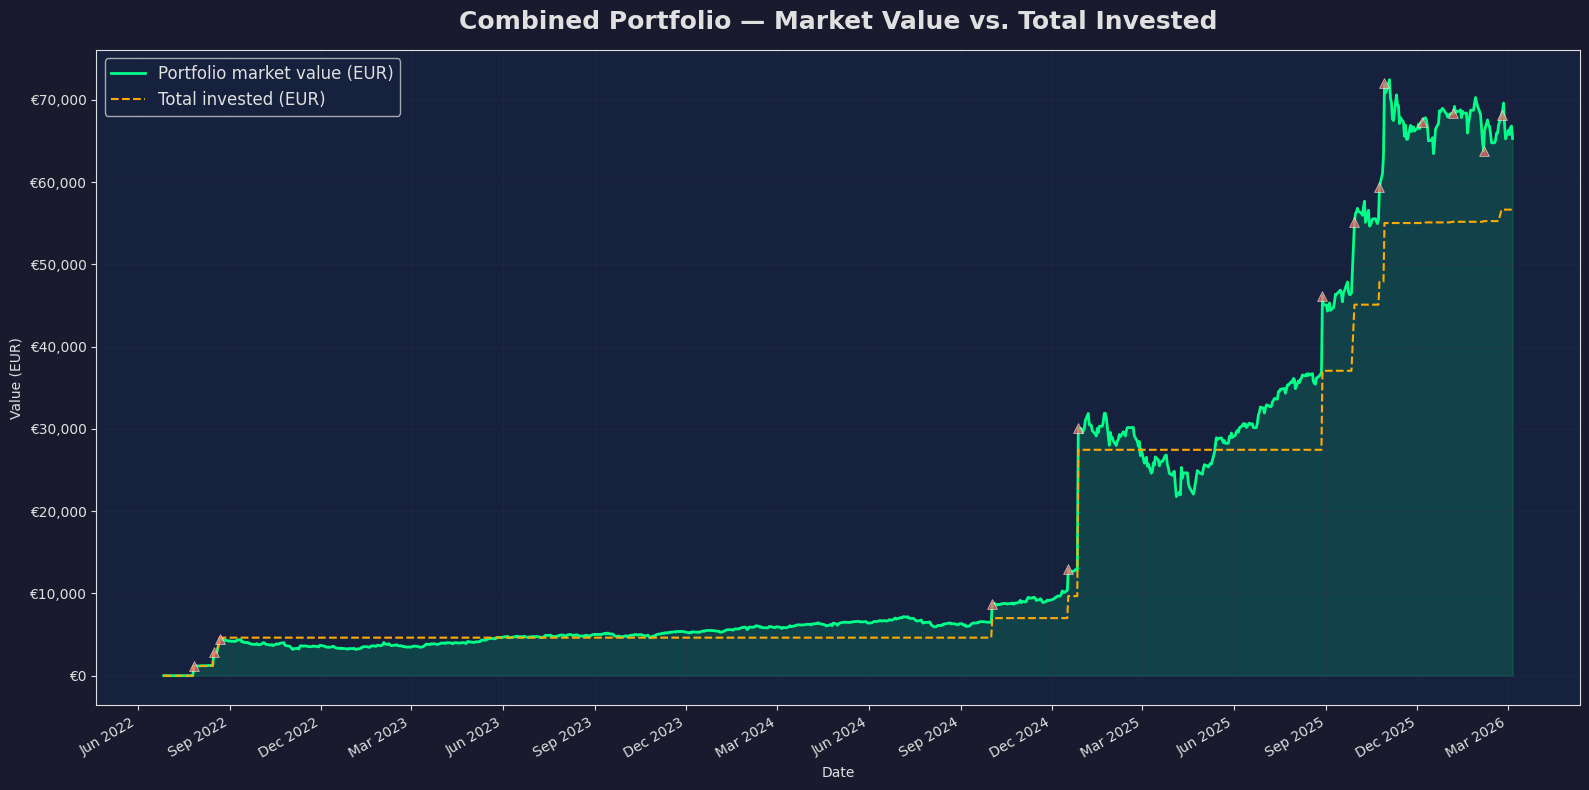


🎉 All done! Charts saved to /content/portefee_charts


In [29]:
print("Generating combined portfolio chart …\n")

# ─── EUR/USD conversion ──────────────────────────────────
# Static approximation; for more accuracy you could pull
# historical EURUSD=X from yfinance
EUR_PER_USD = 0.88

# Build common date range
all_dates = pd.DatetimeIndex([])
for df in prices.values():
    all_dates = all_dates.union(df.index)
all_dates = all_dates.sort_values()

portfolio_value = pd.Series(0.0, index=all_dates)
total_invested = pd.Series(0.0, index=all_dates)
all_buy_events = []

for name, df in prices.items():
    buy_list = BUYS[name]
    ccy = TICKER_CURRENCY.get(name, "EUR")

    price_reindexed = df["price"].reindex(all_dates, method="ffill")
    cum_shares = compute_cumulative_shares(buy_list, all_dates)

    position_value = cum_shares * price_reindexed
    if ccy == "USD":
        position_value *= EUR_PER_USD

    portfolio_value += position_value.fillna(0)

    for date_str, num, price, costs in buy_list:
        dt = pd.Timestamp(date_str)
        amount = num * price + costs
        if ccy == "USD":
            amount *= EUR_PER_USD
        total_invested[total_invested.index >= dt] += amount
        all_buy_events.append((dt, name, num, amount))

# ─── Plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(portfolio_value.index, portfolio_value.values,
        color="#00ff88", linewidth=2,
        label="Portfolio market value (EUR)", zorder=2)
ax.fill_between(portfolio_value.index, portfolio_value.values,
                alpha=0.15, color="#00ff88")

ax.plot(total_invested.index, total_invested.values,
        color="#ffaa00", linewidth=1.5, linestyle="--",
        label="Total invested (EUR)", zorder=2)

# Buy markers
for dt, name, num, amount_eur in all_buy_events:
    idx = portfolio_value.index.get_indexer([dt], method="nearest")[0]
    if 0 <= idx < len(portfolio_value):
        val = portfolio_value.iloc[idx]
        ax.scatter(portfolio_value.index[idx], val,
                   color="#ff6b6b", s=50, zorder=5, alpha=0.7,
                   edgecolors="white", linewidths=0.5, marker="^")

ax.set_title("Combined Portfolio — Market Value vs. Total Invested",
             fontsize=18, fontweight="bold", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Value (EUR)")
ax.legend(loc="upper left", fontsize=12)
ax.grid(True, linewidth=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"€{x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate()
fig.tight_layout()

fpath = os.path.join(OUT_DIR, "COMBINED_PORTFOLIO.png")
fig.savefig(fpath, dpi=150, bbox_inches="tight")
print(f"  ✅ {fpath}")
plt.show()
plt.close(fig)

print(f"\n🎉 All done! Charts saved to {OUT_DIR}")

## 8. Portfolio Summary Table

In [30]:
# ─── Per-position summary ────────────────────────────────
summary_rows = []

for name in BUYS:
    ccy = TICKER_CURRENCY.get(name, "EUR")
    total_shares = sum(num for _, num, _, _ in BUYS[name])
    total_cost = sum(num * price + costs for _, num, price, costs in BUYS[name])
    avg_price = sum(num * price for _, num, price, _ in BUYS[name]) / total_shares

    current_price = None
    if name in prices and len(prices[name]) > 0:
        current_price = prices[name]["price"].iloc[-1]

    # Convert to EUR for portfolio aggregation
    fx = EUR_PER_USD if ccy == "USD" else 1.0
    cost_eur = total_cost * fx

    row = {
        "Ticker": name,
        "Currency": ccy,
        "Shares": total_shares,
        "Avg Buy Price": round(avg_price, 2),
        "Total Cost": round(total_cost, 2),
        "Cost (EUR)": round(cost_eur, 2),
    }

    if current_price is not None:
        market_val = total_shares * current_price
        market_val_eur = market_val * fx
        pl = market_val - total_cost
        pl_eur = market_val_eur - cost_eur
        pl_pct = (market_val - total_cost) / total_cost * 100 if total_cost > 0 else 0
        row["Current Price"] = round(current_price, 2)
        row["Market Value"] = round(market_val, 2)
        row["Value (EUR)"] = round(market_val_eur, 2)
        row["P/L"] = round(pl, 2)
        row["P/L (EUR)"] = round(pl_eur, 2)
        row["P/L %"] = round(pl_pct, 1)
    else:
        row["Current Price"] = "N/A"
        row["Market Value"] = "N/A"
        row["Value (EUR)"] = "N/A"
        row["P/L"] = "N/A"
        row["P/L (EUR)"] = "N/A"
        row["P/L %"] = "N/A"

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

# ─── Portfolio-level aggregates ──────────────────────────
# Filter rows that have numeric P/L values
valid = summary_df[summary_df["P/L (EUR)"] != "N/A"].copy()
valid["Cost (EUR)"] = valid["Cost (EUR)"].astype(float)
valid["Value (EUR)"] = valid["Value (EUR)"].astype(float)
valid["P/L (EUR)"] = valid["P/L (EUR)"].astype(float)

total_cost_eur = valid["Cost (EUR)"].sum()
total_value_eur = valid["Value (EUR)"].sum()
total_pl_eur = valid["P/L (EUR)"].sum()
total_pl_pct = (total_pl_eur / total_cost_eur * 100) if total_cost_eur > 0 else 0

# Time context
earliest_dt = pd.Timestamp(get_earliest_buy(BUYS))
holding_days = (pd.Timestamp.now() - earliest_dt).days
holding_years = holding_days / 365.25
simple_annualized = ((total_value_eur / total_cost_eur) ** (1 / holding_years) - 1) * 100 if holding_years > 0 and total_cost_eur > 0 else 0

# ─── XIRR calculation ────────────────────────────────────
# XIRR = the discount rate that makes NPV of all cash flows = 0
# Outflows (purchases) are negative, final portfolio value is positive
from scipy.optimize import brentq

cashflows = []  # list of (date, amount_eur)

for name in BUYS:
    if name not in prices:
        continue
    ccy = TICKER_CURRENCY.get(name, "EUR")
    fx = EUR_PER_USD if ccy == "USD" else 1.0
    for date_str, num, price, costs in BUYS[name]:
        amount_eur = (num * price + costs) * fx
        cashflows.append((pd.Timestamp(date_str), -amount_eur))  # negative = outflow

# Final inflow: current portfolio value today
cashflows.append((pd.Timestamp.now().normalize(), total_value_eur))

# Sort by date
cashflows.sort(key=lambda x: x[0])

def xnpv(rate, cashflows):
    """Net present value for irregularly spaced cash flows."""
    t0 = cashflows[0][0]
    return sum(
        cf / (1 + rate) ** ((dt - t0).days / 365.25)
        for dt, cf in cashflows
    )

def compute_xirr(cashflows, lo=-0.5, hi=10.0):
    """Find the rate where XNPV = 0 using Brent's method."""
    try:
        return brentq(lambda r: xnpv(r, cashflows), lo, hi, xtol=1e-8)
    except Exception:
        return None

xirr_rate = compute_xirr(cashflows)
xirr_pct = xirr_rate * 100 if xirr_rate is not None else None

# Display per-position table
print("📊 Per-Position Summary")
print("=" * 40)
display(summary_df)

# Display portfolio aggregate
print()
print("═" * 60)
print("🧚 PORTEFEE — PORTFOLIO AGGREGATE")
print("═" * 60)
print(f"  Positions tracked:      {len(valid)} / {len(summary_df)}")
print(f"  Total invested (EUR):   €{total_cost_eur:>12,.2f}")
print(f"  Current value (EUR):    €{total_value_eur:>12,.2f}")
print(f"  ──────────────────────────────────────")
pl_sign = "+" if total_pl_eur >= 0 else ""
pl_emoji = "📈" if total_pl_eur >= 0 else "📉"
print(f"  {pl_emoji} Total P/L (EUR):      {pl_sign}€{total_pl_eur:>11,.2f}  ({pl_sign}{total_pl_pct:.1f}%)")
print(f"  ──────────────────────────────────────")
print(f"  Holding period:         {holding_days} days ({holding_years:.1f} years)")
print(f"  Simple annualized:      {pl_sign}{simple_annualized:.1f}%  (assumes lump sum)")
if xirr_pct is not None:
    xirr_sign = "+" if xirr_pct >= 0 else ""
    print(f"  XIRR annualized:        {xirr_sign}{xirr_pct:.1f}%  (accounts for timing of buys)")
else:
    print(f"  XIRR annualized:        could not converge")
print(f"  ──────────────────────────────────────")
print(f"  Compare to benchmarks:")
print(f"    S&P 500 avg:          ~10-11% / year")
print(f"    MSCI World avg:       ~8-9% / year")
print(f"    Euro savings rate:    ~2-3% / year")
if xirr_pct is not None:
    print(f"  ──────────────────────────────────────")
    print(f"  💡 XIRR is the most accurate measure")
    print(f"     for your portfolio since it accounts")
    print(f"     for the actual timing and size of")
    print(f"     each individual purchase.")
print(f"═" * 60)

📊 Per-Position Summary


,Ticker,Currency,Shares,Avg Buy Price,Total Cost,Cost (EUR),Current Price,Market Value,Value (EUR),P/L,P/L (EUR),P/L %
0,MSFT,USD,24,459.64,11059.04,9731.96,408.96,9815.04,8637.24,-1244.00,-1094.72,-11.2
1,GOOGL,USD,43,177.77,7704.79,6780.22,298.52,12836.36,11296.00,5131.57,4515.78,66.6
2,NVDA,USD,255,156.94,40267.96,35435.80,177.82,45344.10,39902.81,5076.14,4467.00,12.6
3,AMZN,USD,28,180.22,5093.81,4482.55,213.21,5969.88,5253.49,876.07,770.94,17.2
4,BEL20,EUR,3,77.99,234.26,234.26,76.98,230.94,230.94,-3.32,-3.32,-1.4



════════════════════════════════════════════════════════════
🧚 PORTEFEE — PORTFOLIO AGGREGATE
════════════════════════════════════════════════════════════
  Positions tracked:      5 / 5
  Total invested (EUR):   €   56,664.79
  Current value (EUR):    €   65,320.48
  ──────────────────────────────────────
  📈 Total P/L (EUR):      +€   8,655.68  (+15.3%)
  ──────────────────────────────────────
  Holding period:         1320 days (3.6 years)
  Simple annualized:      +4.0%  (assumes lump sum)
  XIRR annualized:        +14.5%  (accounts for timing of buys)
  ──────────────────────────────────────
  Compare to benchmarks:
    S&P 500 avg:          ~10-11% / year
    MSCI World avg:       ~8-9% / year
    Euro savings rate:    ~2-3% / year
  ──────────────────────────────────────
  💡 XIRR is the most accurate measure
     for your portfolio since it accounts
     for the actual timing and size of
     each individual purchase.
════════════════════════════════════════════════════════════